In [ ]:
#Adding imports for working on Dataset and visualizations
import pandas as pd
import matplotlib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Defining path to load data
data_path = "Dataset/sales_data.csv"
ad_df = pd.read_csv(data_path)

# To display them organized
ad_df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [22]:
# TO drop unnecessary index columns if they exist
if 'Unnamed: 0' in ad_df.columns:
    ad_df = ad_df.drop(columns=['Unnamed: 0'])

# Separate features (inputs) from targets (output)
tgt_col = 'Sales'
feat_cols = ad_df.drop(columns=[tgt_col])
tgt_val = ad_df[tgt_col]

# Splitting into 80% - 20% training- testing ratio
tr_x, ts_x, tr_y, ts_y = train_test_split(
    feat_cols, tgt_val, test_size=0.2, random_state=42
)

print(f"No. of Training rows: {tr_x.shape[0]}")
print(f"No. of Testing rows: {ts_x.shape[0]}")

No. of Training rows: 160
No. of Testing rows: 40


In [23]:
# Using Random Forest. initializing to train model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(tr_x, tr_y)

print("training of model is completed !")

training of model is completed !


In [24]:
from sklearn.metrics import mean_absolute_error

# Predict on the test set
preds = rf_model.predict(ts_x)

# Here we calculated accuracy metrics
ms_err = mean_squared_error(ts_y, preds)
mae_err = mean_absolute_error(ts_y, preds)
r2_acc = r2_score(ts_y, preds)

# Converted R-squared to a percentage for showing accuracy in percentage
acc_pct = r2_acc * 100

print(f"Mean Squared Error: {ms_err:.2f}")
print(f"Mean Absolute Error: {mae_err:.2f} (predictions are off by this average)")
print(f"Model Accuracy (R-Squared): {acc_pct:.2f}%")

Mean Squared Error: 0.59
Mean Absolute Error: 0.62 (predictions are off by this average)
Model Accuracy (R-Squared): 98.13%


In [25]:

# Set a beautiful visual style for our charts
# sns.set_theme(style="whitegrid")
print("Visualization tools loaded!")

Visualization tools loaded!


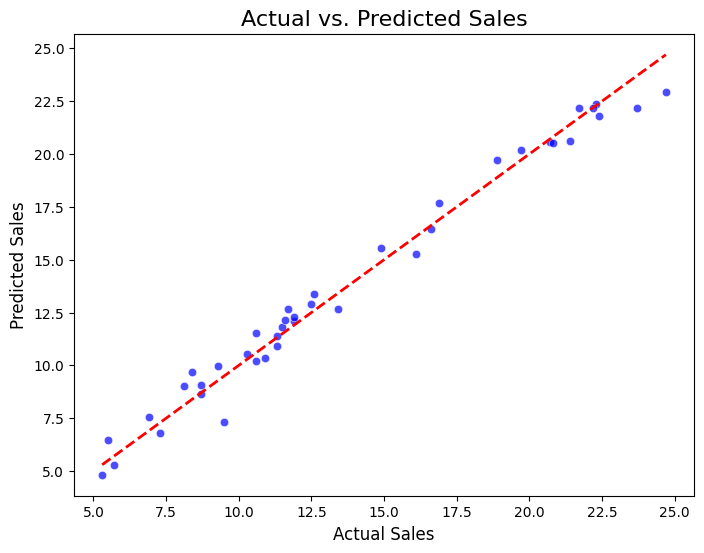

In [26]:
plt.figure(figsize=(8, 6))

# Create the scatter plot
sns.scatterplot(x=ts_y, y=preds, color="blue", alpha=0.7)

# Draw a red line showing predictions
plt.plot([ts_y.min(), ts_y.max()], [ts_y.min(), ts_y.max()], color="red", linestyle="--", linewidth=2)

plt.title("Actual vs. Predicted Sales", fontsize=16)
plt.xlabel("Actual Sales", fontsize=12)
plt.ylabel("Predicted Sales", fontsize=12)
plt.show()

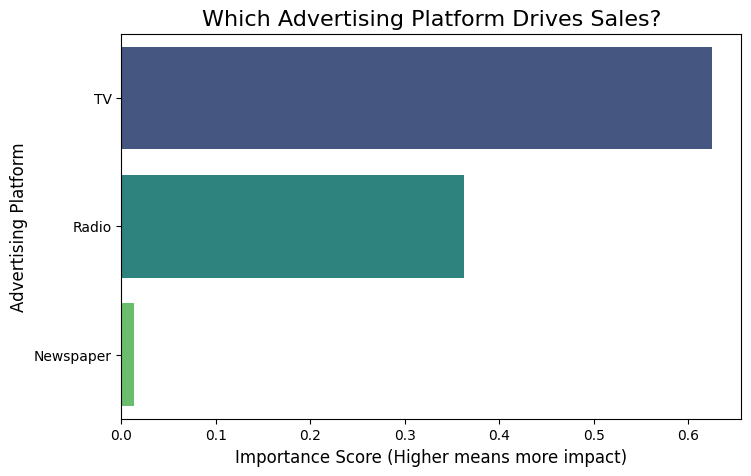

In [27]:
plt.figure(figsize=(8, 5))

# Extracting importance scores from the trained engine
importance_scores = rf_model.feature_importances_
feat_names = feat_cols.columns

# Creating a bar chart with colors
sns.barplot(x=importance_scores, y=feat_names, palette="viridis", hue=feat_names, legend=False)

plt.title("Which Advertising Platform Drives Sales?", fontsize=16)
plt.xlabel("Importance Score (Higher means more impact)", fontsize=12)
plt.ylabel("Advertising Platform", fontsize=12)
plt.show()

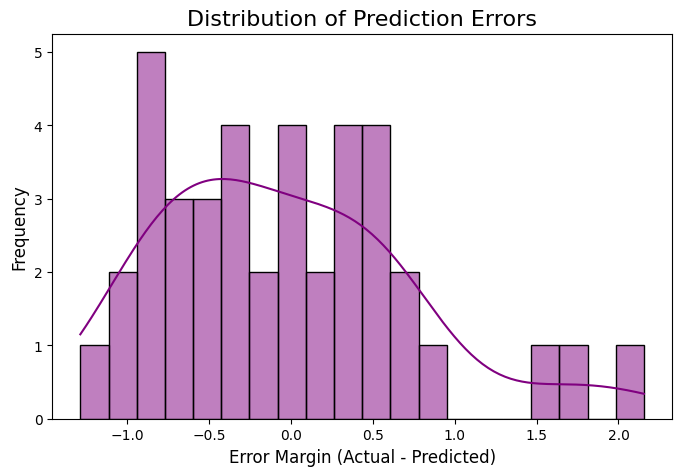

In [28]:
plt.figure(figsize=(8, 5))

# Calculate the errors (Actual - Predicted)
errors = ts_y - preds

# Plotting a histogram of the errors
sns.histplot(errors, bins=20, kde=True, color="purple")

plt.title("Distribution of Prediction Errors", fontsize=16)
plt.xlabel("Error Margin (Actual - Predicted)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()